#PROJECT 1 : STUDENT ANALYTICS DASHBOARD

# Import Libraries

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Database
import sqlite3

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Dataset (CSV -> Pandas)

In [ ]:
# Load CSV file

df = pd.read_csv("student_performance.csv")
print('Dataset Loaded successfully')

Dataset Loaded successfully


In [ ]:
# Display first 5 rows
print(df.head())

   student_id          name  age  gender        department  semester  \
0        1001  Aarav Sharma   19    Male  Computer Science         2   
1        1002   Priya Patel   20  Female  Computer Science         2   
2        1003   Rohit Verma   19    Male       Electronics         2   
3        1004   Sneha Reddy   20  Female        Mechanical         2   
4        1005    Arjun Nair   19    Male  Computer Science         2   

   math_score  science_score  english_score  programming_score  \
0          85             78             72                 91   
1          76             82             88                 79   
2          65             74             61                 55   
3          70             80             75                 48   
4          92             88             81                 95   

   attendance_percentage       city  admission_year  
0                     92     Mumbai            2023  
1                     87  Ahmedabad            2023  
2       

In [ ]:
# Dataset information
print("\nDataset Info")
print(df.info())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int64 
 11  city                   30 non-null     object
 12  admission_year         30 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 3.2+ KB
None


In [ ]:
# Check null values
print("\nMissing Values")
print(df.isnull().sum())



Missing Values
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [ ]:
# Statistical Summary
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
        student_id        age  semester  math_score  science_score  \
count    30.000000  30.000000      30.0   30.000000      30.000000   
mean   1015.500000  19.733333       2.0   76.066667      77.833333   
std       8.803408   0.739680       0.0   11.467896       8.554423   
min    1001.000000  19.000000       2.0   56.000000      61.000000   
25%    1008.250000  19.000000       2.0   67.250000      71.250000   
50%    1015.500000  20.000000       2.0   75.500000      78.000000   
75%    1022.750000  20.000000       2.0   85.750000      83.750000   
max    1030.000000  21.000000       2.0   95.000000      93.000000   

       english_score  programming_score  attendance_percentage  admission_year  
count      30.000000          30.000000              30.000000            30.0  
mean       74.166667          67.600000              84.500000          2023.0  
std        10.003735          21.041175               9.379913             0.0  
min        55.000000     

#ETL Cleaning

In [ ]:
# Remove duplicate records

df = df.drop_duplicates()

# Handle missing values

df = df.fillna(0)

# Verify cleaning

print("Dataset Shape:", df.shape)
print(df.isnull().sum())

Dataset Shape: (30, 13)
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


#Store Data in SQLite Database

In [ ]:
# Create database connection

conn = sqlite3.connect("student.db")

# Store dataframe into SQL table

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data Stored Successfully")

Data Stored Successfully


#SQL Analysis Queries
#Query 1 : Total Students

In [ ]:
query = """
SELECT COUNT(*) AS total_students
FROM students;
"""

result = pd.read_sql(query, conn)
result

,total_students
0,30


#Query 2: Department Wise Average Programming Score

In [ ]:
query = """
SELECT department,
AVG(programming_score) AS avg_programming_score
FROM students
GROUP BY department;
"""

result = pd.read_sql(query, conn)
result

,department,avg_programming_score
0,Civil,40.600000
1,Computer Science,89.230769
2,Electronics,61.500000
3,Mechanical,49.333333


#Query 3: Department Wise Attendance

In [ ]:
query = """
SELECT department,
AVG(attendance_percentage) AS avg_attendance
FROM students
GROUP BY department;
"""

result = pd.read_sql(query, conn)
result

,department,avg_attendance
0,Civil,74.600000
1,Computer Science,90.692308
2,Electronics,80.333333
3,Mechanical,83.500000


#Query 4: Students Scoring Above 80 in Math

In [ ]:
query = """
SELECT *
FROM students
WHERE math_score > 80;
"""

result = pd.read_sql(query, conn)
result

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023
2,1008,Divya Singh,19,Female,Computer Science,2,88,91,84,93,96,Lucknow,2023
3,1010,Ananya Das,19,Female,Computer Science,2,95,89,90,97,98,Kolkata,2023
4,1013,Suresh Rao,21,Male,Computer Science,2,83,86,77,88,88,Mysore,2023
5,1016,Ritu Agarwal,20,Female,Electronics,2,87,83,86,69,93,Agra,2023
6,1018,Swati Kulkarni,19,Female,Computer Science,2,90,87,85,92,94,Nagpur,2023
7,1022,Tanvi Mehta,19,Female,Computer Science,2,93,90,88,96,97,Surat,2023
8,1025,Amit Bose,19,Male,Computer Science,2,86,82,79,89,91,Kolkata,2023
9,1027,Gaurav Shukla,21,Male,Computer Science,2,84,79,75,87,87,Lucknow,2023


#Query 5: Top 5 Students by Total Score

In [ ]:
query = """
SELECT name,
(math_score + science_score + programming_score) AS total_score
FROM students
ORDER BY total_score DESC
LIMIT 5;
"""

result = pd.read_sql(query, conn)
result

,name,total_score
0,Ananya Das,281
1,Tanvi Mehta,279
2,Akanksha Yadav,278
3,Arjun Nair,275
4,Divya Singh,272


#Visualization
#Chart 1: Department Average Programming Score

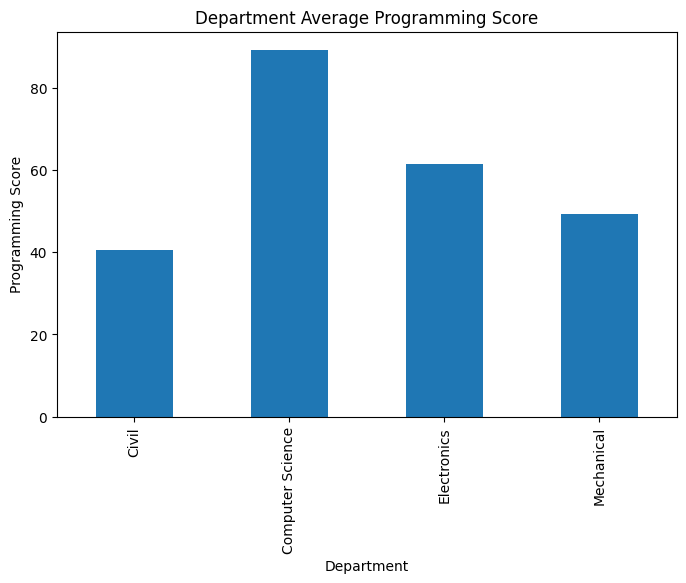

In [ ]:
dept_avg = df.groupby("department")["programming_score"].mean()

plt.figure(figsize=(8,5))
dept_avg.plot(kind="bar")

plt.title("Department Average Programming Score")
plt.xlabel("Department")
plt.ylabel("Programming Score")

plt.show()

#Chart 2: Attendance Distribution

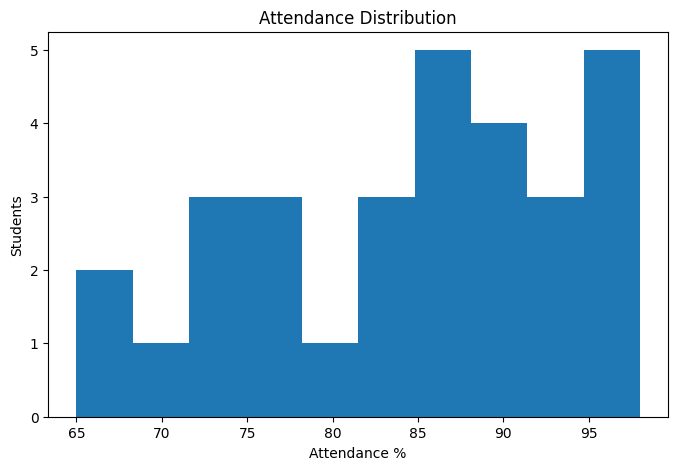

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df["attendance_percentage"],
    bins=10
)

plt.title("Attendance Distribution")
plt.xlabel("Attendance %")
plt.ylabel("Students")

plt.show()

#Chart 3: Math Score vs Programming Score

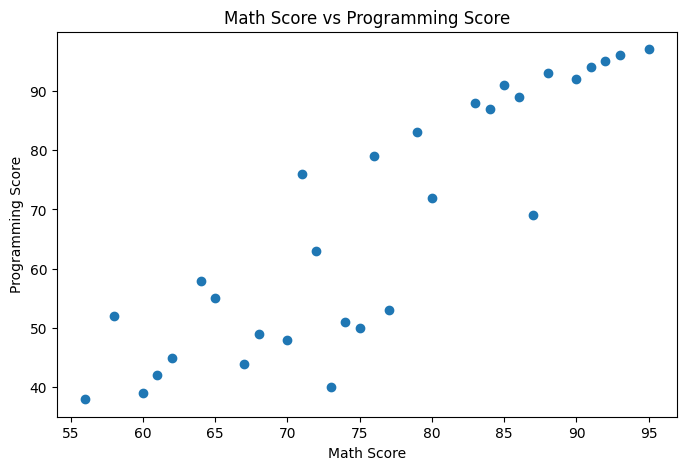

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["math_score"],
    df["programming_score"]
)

plt.title("Math Score vs Programming Score")
plt.xlabel("Math Score")
plt.ylabel("Programming Score")

plt.show()

#Step 7: Machine Learning Prediction
#Predict Programming Score

In [ ]:
# Features

X = df[
    [
        "math_score",
        "science_score",
        "attendance_percentage"
    ]
]

# Target

y = df["programming_score"]

#Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Train Random Forest

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


#Prediction

In [ ]:
predictions = model.predict(X_test)

print("Predicted Scores:")
print(predictions[:10])

Predicted Scores:
[49.93 89.85 71.95 93.2  48.81 95.07]


#Evaluation

In [ ]:
mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 9.611666666666668
MSE: 155.49515000000002
R2 Score: 0.6874294823831593


#Step 8: Predict New Student

In [ ]:
new_student = pd.DataFrame({
    "math_score":[85],
    "science_score":[80],
    "attendance_percentage":[92]
})

prediction = model.predict(new_student)

print(
    "Predicted Programming Score:",
    prediction[0]
)

Predicted Programming Score: 88.11


#Step 9: Business Report

In [ ]:
print("\n========== BUSINESS REPORT ==========")

print(
    "Total Students:",
    len(df)
)

print(
    "Average Programming Score:",
    round(df["programming_score"].mean(),2)
)

print(
    "Average Attendance:",
    round(df["attendance_percentage"].mean(),2)
)

print(
    "Highest Programming Score:",
    df["programming_score"].max()
)

print(
    "Lowest Programming Score:",
    df["programming_score"].min()
)

best_dept = (
    df.groupby("department")
      ["programming_score"]
      .mean()
      .idxmax()
)

print(
    "Best Performing Department:",
    best_dept
)

print("\nInsights")

print(
    "1. Students with higher attendance generally score better."
)

print(
    "2. Programming performance varies across departments."
)

print(
    "3. Random Forest can predict programming score using academic metrics."
)


========== BUSINESS REPORT ==========
Total Students: 30
Average Programming Score: 67.6
Average Attendance: 84.5
Highest Programming Score: 97
Lowest Programming Score: 38
Best Performing Department: Computer Science

Insights
1. Students with higher attendance generally score better.
2. Programming performance varies across departments.
3. Random Forest can predict programming score using academic metrics.


#Close Database

In [ ]:
conn.close()

#PROJECT 2 : WEATHER INTELLIGENCE SYSTEM

#Import Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Database
import sqlite3

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Load Weather Dataset

In [ ]:
# Load weather dataset

df = pd.read_csv("weather.csv")

# Display first rows
print("First 5 Records")
print(df.head())

# Dataset information
print("\nDataset Info")
print(df.info())

# Missing values
print("\nMissing Values")
print(df.isnull().sum())

First 5 Records
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0        

#ETL Cleaning
#Remove duplicates and fill missing values

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values

df = df.fillna(df.mean(numeric_only=True))

print("Dataset Shape:", df.shape)

Dataset Shape: (96429, 12)


#Validate Weather Fields

In [ ]:
# Remove impossible temperature values

df = df[
    (df["Temperature (C)"] >= -50) &
    (df["Temperature (C)"] <= 60)
]

# Remove impossible humidity values

df = df[
    (df["Humidity"] >= 0) &
    (df["Humidity"] <= 100)
]

# Remove negative wind speeds

df = df[
    df["Wind Speed (km/h)"] >= 0
]

print("Validated Records:", len(df))

Validated Records: 96429


#Compute Heat Index

In [ ]:
# Calculate Heat Index

df["heat_index"] = (
    df["Temperature (C)"] +
    (0.1 * df["Humidity"])
)

print(df[["Temperature (C)",
          "Humidity",
          "heat_index"]].head())

   Temperature (C)  Humidity  heat_index
0         9.472222      0.89    9.561222
1         9.355556      0.86    9.441556
2         9.377778      0.89    9.466778
3         8.288889      0.83    8.371889
4         8.755556      0.83    8.838556


#Store Data in SQLite

In [ ]:
# Create SQLite database

conn = sqlite3.connect("weather.db")

# Store dataframe

df.to_sql(
    "weather",
    conn,
    if_exists="replace",
    index=False
)

print("Weather data stored successfully")

Weather data stored successfully


#SQL Analysis Queries

#Query 1: Average Temperature

In [ ]:
query = """
SELECT AVG("Temperature (C)") AS average_temperature
FROM weather;
"""

result = pd.read_sql(query, conn)
print(result)

   average_temperature
0            11.929692


#Query 2: Maximum Temperature

In [ ]:
query = """
SELECT MAX("Temperature (C)") AS max_temperature
FROM weather;
"""

result = pd.read_sql(query, conn)
print(result)

   max_temperature
0        39.905556


#Query 3: Average Humidity

In [ ]:
query = """
SELECT AVG(humidity) AS average_humidity
FROM weather;
"""

result = pd.read_sql(query, conn)
print(result)

   average_humidity
0          0.734902


#Query 4: Highest Wind Speed

In [ ]:
query = """
SELECT MAX("Wind Speed (km/h)") AS highest_wind
FROM weather;
"""

result = pd.read_sql(query, conn)
print(result)

   highest_wind
0       63.8526


#Query 5: Top 5 Hottest Days

In [ ]:
query = """
SELECT *
FROM weather
ORDER BY "Temperature (C)" DESC
LIMIT 5;
"""

result = pd.read_sql(query, conn)
print(result)

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2007-07-22 15:00:00.000 +0200          Clear        rain        39.905556   
1  2007-07-21 17:00:00.000 +0200  Partly Cloudy        rain        39.588889   
2  2007-07-19 16:00:00.000 +0200  Partly Cloudy        rain        38.983333   
3  2007-07-20 15:00:00.000 +0200  Partly Cloudy        rain        38.983333   
4  2007-07-20 16:00:00.000 +0200  Partly Cloudy        rain        38.983333   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                 37.538889      0.13            23.5865   
1                 37.600000      0.15            12.2038   
2                 37.461111      0.18             8.9355   
3                 36.627778      0.14            12.7190   
4                 36.800000      0.15            15.4077   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   250.0           9.9820         0.0               1007.55  

#Step 8: Visualization
#Temperature Chart

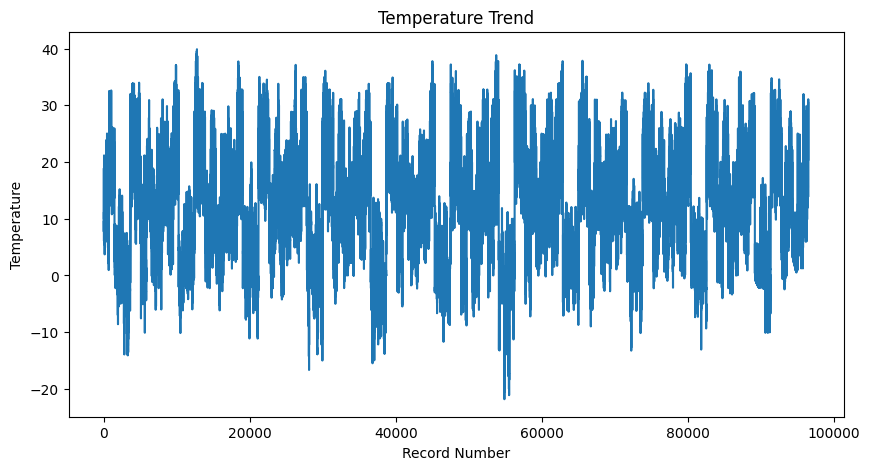

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Temperature (C)"])

plt.title("Temperature Trend")
plt.xlabel("Record Number")
plt.ylabel("Temperature")

plt.show()

#Humidity Chart

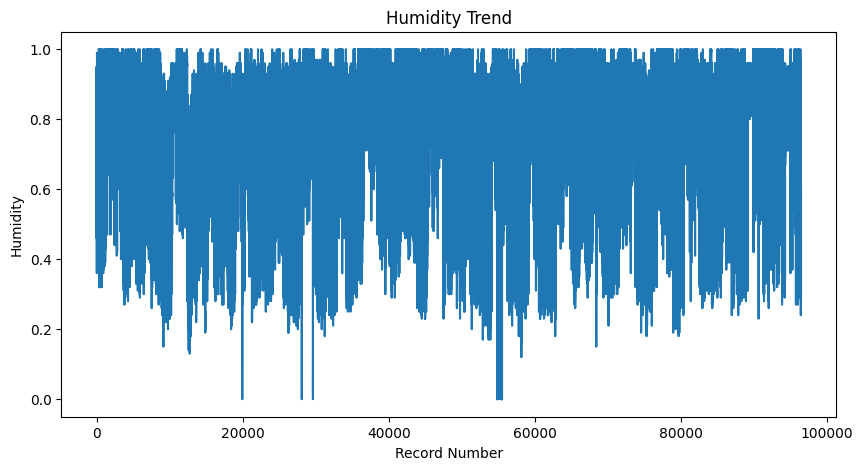

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Humidity"])

plt.title("Humidity Trend")
plt.xlabel("Record Number")
plt.ylabel("Humidity")

plt.show()

#Wind Speed Chart

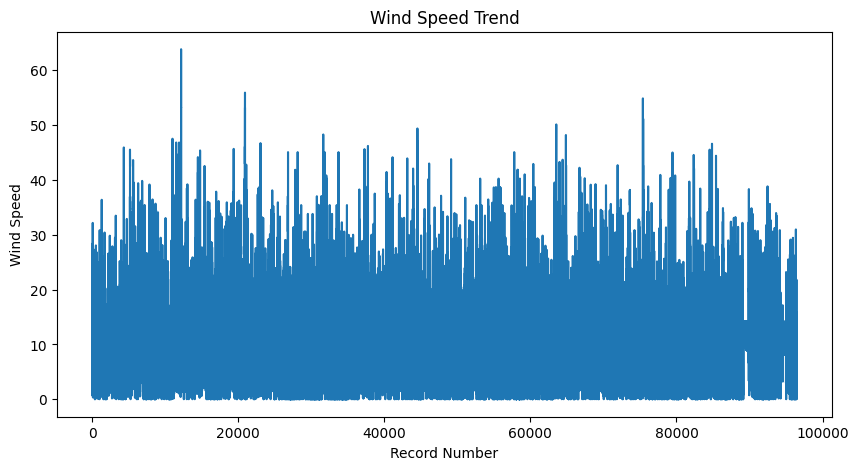

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Wind Speed (km/h)"])

plt.title("Wind Speed Trend")
plt.xlabel("Record Number")
plt.ylabel("Wind Speed")

plt.show()

#Heat Index Distributio

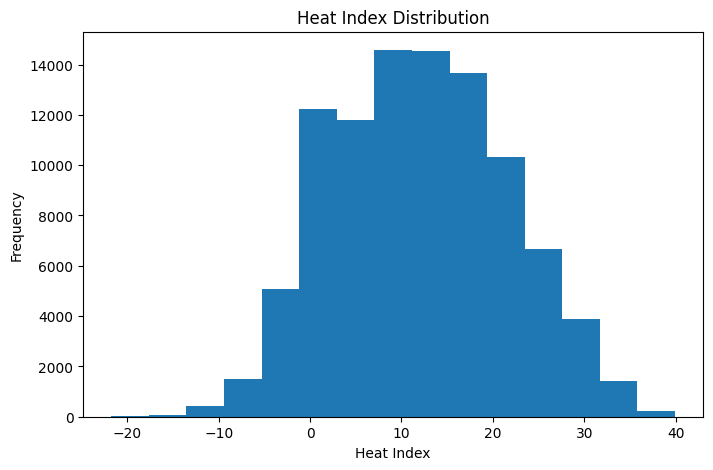

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df["heat_index"],
    bins=15
)

plt.title("Heat Index Distribution")
plt.xlabel("Heat Index")
plt.ylabel("Frequency")

plt.show()

#Machine Learning
#Predict Humidity using Temperature and Wind Speed
#Features and Targetm

In [ ]:
# Features

X = df[
    [
        "Temperature (C)",
        "Wind Speed (km/h)"
    ]
]

# Target

y = df["Humidity"]

#Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#Train Random Forest Model

In [ ]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model Training Complete")

Model Training Complete


#Prediction

In [ ]:
predictions = model.predict(X_test)

print("Predictions")
print(predictions[:10])

Predictions
[0.772      0.9049     0.763      0.820875   0.4562     0.32087035
 0.4024     0.6556746  0.9203     0.78723333]


#Model Evaluation

In [ ]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("MSE :", mse)
print("R2 Score :", r2)

MAE : 0.10970359937208375
MSE : 0.020237316532474944
R2 Score : 0.47546321996226715


#Predict Humidity for New Weather Conditions

In [ ]:
new_weather = pd.DataFrame({
    "Temperature (C)":[35],
    "Wind Speed (km/h)":[12]
})

predicted_humidity = model.predict(
    new_weather
)

print(
    "Predicted Humidity:",
    predicted_humidity[0]
)

Predicted Humidity: 0.25929999999999986


#Business Report

In [ ]:
print("\n===== WEATHER INTELLIGENCE REPORT =====")

print(
    "Average Temperature:",
    round(df["Temperature (C)"].mean(),2)
)

print(
    "Average Humidity:",
    round(df["Humidity"].mean(),2)
)

print(
    "Maximum Temperature:",
    df["Temperature (C)"].max()
)

print(
    "Maximum Wind Speed:",
    df["Wind Speed (km/h)"].max()
)

print(
    "Average Heat Index:",
    round(df["heat_index"].mean(),2)
)

print("\nInsights")

print(
    "1. Temperature and humidity strongly influence heat index."
)

print(
    "2. Wind speed affects weather comfort levels."
)

print(
    "3. Machine Learning can estimate humidity using temperature and wind speed."
)

print(
    "4. Heat index helps identify potentially uncomfortable weather conditions."
)



===== WEATHER INTELLIGENCE REPORT =====
Average Temperature: 11.93
Average Humidity: 0.73
Maximum Temperature: 39.90555555555555
Maximum Wind Speed: 63.8526
Average Heat Index: 12.0

Insights
1. Temperature and humidity strongly influence heat index.
2. Wind speed affects weather comfort levels.
3. Machine Learning can estimate humidity using temperature and wind speed.
4. Heat index helps identify potentially uncomfortable weather conditions.


#lose Database